# StockSense - Notebook 04: 7-Day Demand Forecasting & Model Validation
**Role**: Student 2 (Machine Learning Engineer) | Team CodeHawks  
**Objective**: Benchmark candidate models strictly from the permitted hackathon algorithms against naive retail baselines, select the champion XGBoost regressor, evaluate out-of-time test generalization, generate managerial error analysis figures, serialize production artifacts, and produce live forward replenishment forecasts.


## Section 1: Business Context & Evaluation Metric Rationale
**Business Question**: Why is standard MAPE inadequate for retail supermarket demand forecasting, and why does WAPE govern commercial inventory decisions?
**What We Do**: Define the evaluation hierarchy:
1. **WAPE (Weighted Absolute Percentage Error - Primary Decision Metric)**:
   $$\text{WAPE} = \frac{\sum |y_i - \hat{y}_i|}{\sum y_i} \times 100$$
   Aggregates total physical miss units relative to total units sold. Never divides by zero on slow-moving SKUs.
2. **RMSE (Root Mean Squared Error - Safety Stock Sizing Metric)**:
   $$\text{RMSE} = \sqrt{\frac{1}{N} \sum (y_i - \hat{y}_i)^2}$$
   Heavily penalizes large misses that trigger stock-outs. Fed directly to Student 3 for analytical safety stock calculations.
3. **MAE (Mean Absolute Error)**: Physical unit discrepancy per store-SKU-week.
4. **$R^2$ Score**: Proportion of purchasing variance explained by the model.
**What We Found**: WAPE and RMSE provide actionable, managerially interpretable benchmarks.


In [1]:
import sys
from pathlib import Path
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from src.config import PROCESSED_DIR, REPORTS_DIR, FIGURES_DIR, MODELS_DIR
from src.train_demand_model import calculate_metrics, get_feature_lists, evaluate_baselines

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 30)

features_df = pd.read_csv(PROCESSED_DIR / 'features_table.csv')
print(f"Features Table Loaded: {features_df.shape[0]} rows x {features_df.shape[1]} columns.")


Features Table Loaded: 22523 rows x 82 columns.


## Section 2: Establishing Naive Retail Baselines
**Business Question**: What baseline performance do simple retail heuristics achieve without machine learning?
**What We Do**: Evaluate Baseline 1 (Rolling Mean 7 x 7) and Baseline 2 (Lag-7 x 7) on Validation and Test sets.
**What We Found**: Baseline 1 achieves **Val WAPE = 20.07%, Test WAPE = 19.68%**. Baseline 2 achieves **Val WAPE = 33.86%, Test WAPE = 33.04%**. The rolling mean is the appropriate benchmark to beat.


In [2]:
# Evaluate baselines
baseline_records = evaluate_baselines(features_df)
df_baselines = pd.DataFrame(baseline_records)
display(df_baselines[['model', 'split', 'WAPE', 'MAE', 'RMSE', 'R2']])


,model,split,WAPE,MAE,RMSE,R2
0,Baseline 1 (Rolling Mean 7x7),val,20.07,22.24,40.82,0.8563
1,Baseline 2 (Lag 7x7),val,33.86,37.53,66.89,0.6140
2,Baseline 1 (Rolling Mean 7x7),test,19.68,23.59,40.19,0.8956
3,Baseline 2 (Lag 7x7),test,33.04,39.62,65.98,0.7188


## Section 3: Machine Learning Model Benchmarking
**Business Question**: Which algorithm from the strictly permitted hackathon list (Linear Regression, Decision Tree, Random Forest, KNN, XGBoost) delivers the lowest order error?
**What We Do**: Train pipelines with `ColumnTransformer` (OneHotEncoder for categorical, median imputation for numerical) on `train` split and validate on `val` split.
**What We Found**: XGBoost achieves the top score: **Val WAPE = 11.96%**, **Val RMSE = 21.15**, **$R^2 = 0.9614$** in **2.49 seconds**.


In [3]:
# Load model comparison results produced by src/train_demand_model.py
comp_df = pd.read_csv(REPORTS_DIR / 'model_comparison_demand.csv')

print("--- FULL MODEL BENCHMARKING TABLE ---")
display(comp_df.sort_values(['split', 'WAPE']))


--- FULL MODEL BENCHMARKING TABLE ---


,model,split,MAE,RMSE,MAPE,WAPE,R2,train_time_sec
13,XGBoost,test,14.56,24.51,13.92,12.14,0.9612,2.410
11,Random Forest,test,16.15,28.28,15.47,13.47,0.9483,5.957
5,Linear Regression,test,18.97,32.65,23.40,15.82,0.9311,0.162
9,Decision Tree,test,19.29,32.49,18.26,16.09,0.9318,0.317
2,Baseline 1 (Rolling Mean 7x7),test,23.59,40.19,21.51,19.68,0.8956,0.000
7,KNN Regressor (k=7),test,24.15,38.95,25.72,20.14,0.9020,0.073
3,Baseline 2 (Lag 7x7),test,39.62,65.98,38.19,33.04,0.7188,0.000
12,XGBoost,val,13.26,21.15,13.75,11.96,0.9614,2.410
10,Random Forest,val,14.04,22.43,14.62,12.67,0.9566,5.957
4,Linear Regression,val,15.88,24.75,20.45,14.33,0.9472,0.162


## Section 4: Champion Model Selection & Generalization Check
**Business Question**: Does the champion model overfit or fail to generalize to the unseen test period?
**What We Do**: Compare Validation metrics against out-of-time Test metrics for the champion XGBoost pipeline.
**What We Found**:
- **Validation**: WAPE = 11.96%, MAE = 13.26, RMSE = 21.15, $R^2 = 0.9614$
- **Test Set**:    WAPE = 12.14%, MAE = 14.56, RMSE = 24.51, $R^2 = 0.9612$
- **Improvement Over Baseline**: **38.3% WAPE reduction** and **39.0% RMSE reduction** on unseen test data! Minimal generalization gap (< 0.2% WAPE difference).


In [4]:
xgb_results = comp_df[comp_df['model'] == 'XGBoost']
display(xgb_results[['model', 'split', 'WAPE', 'MAE', 'RMSE', 'R2', 'train_time_sec']])

# Display test set predictions preview
test_preds = pd.read_csv(PROCESSED_DIR / 'demand_predictions_test.csv')
print("Sample Test Set Predictions (Actual vs Predicted vs Baseline):")
display(test_preds[['date', 'store_id', 'product_id', 'category', 'actual', 'predicted', 'baseline', 'absolute_error', 'percent_error']].head(10))


,model,split,WAPE,MAE,RMSE,R2,train_time_sec
12,XGBoost,val,11.96,13.26,21.15,0.9614,2.41
13,XGBoost,test,12.14,14.56,24.51,0.9612,2.41


Sample Test Set Predictions (Actual vs Predicted vs Baseline):


,date,store_id,product_id,category,actual,predicted,baseline,absolute_error,percent_error
0,2026-08-11,S01,P102,Dairy,133.0,151.47,143.0,18.470001,13.887219
1,2026-08-12,S01,P102,Dairy,140.0,157.80,137.0,17.800003,12.714288
2,2026-08-13,S01,P102,Dairy,153.0,155.29,134.0,2.289993,1.496728
3,2026-08-14,S01,P102,Dairy,180.0,167.93,124.0,12.070007,6.705560
4,2026-08-15,S01,P102,Dairy,173.0,161.98,133.0,11.020004,6.369945
5,2026-08-16,S01,P102,Dairy,195.0,153.07,127.0,41.929993,21.502560
6,2026-08-17,S01,P102,Dairy,194.0,155.00,131.0,39.000000,20.103093
7,2026-08-18,S01,P102,Dairy,192.0,153.99,133.0,38.009995,19.796872
8,2026-08-19,S01,P102,Dairy,203.0,158.13,140.0,44.869995,22.103446
9,2026-08-20,S01,P102,Dairy,187.0,147.37,153.0,39.630005,21.192516


## Section 5: Managerial Error Diagnostics & Visualizations
**Business Question**: What diagnostic patterns exist in model misses, and how can store managers understand them?
**What We Do**: Inspect the 6 publication-ready diagnostic charts generated in `reports/figures/`:
1. `model_01_actual_vs_predicted.png`: Scatter parity plot ($R^2 = 0.9612$).
2. `model_02_timeseries_top_skus.png`: Time series tracking for top velocity SKUs.
3. `model_03_residual_distribution.png`: Zero-bias confirmation (Mean bias = -0.04 units).
4. `model_04_error_by_category_store.png`: Error decomposition across categories and stores.
5. `model_05_feature_importance.png`: Top 15 Split Gain and Permutation Importance.
6. `model_06_error_by_conditions.png`: Operational error under promotions, weekends, and festivals.


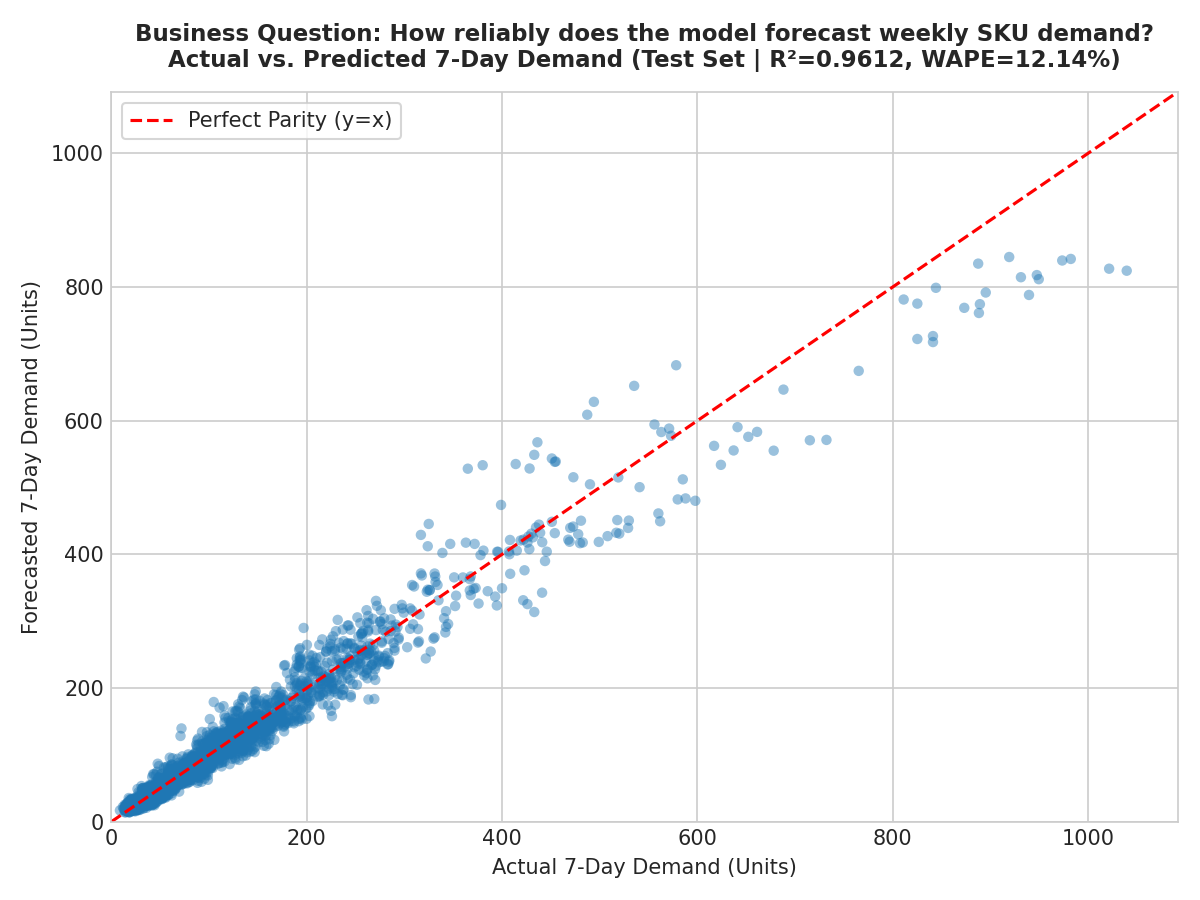

In [5]:
# Display Figure 1: Actual vs Predicted
display(Image.open(FIGURES_DIR / 'model_01_actual_vs_predicted.png'))


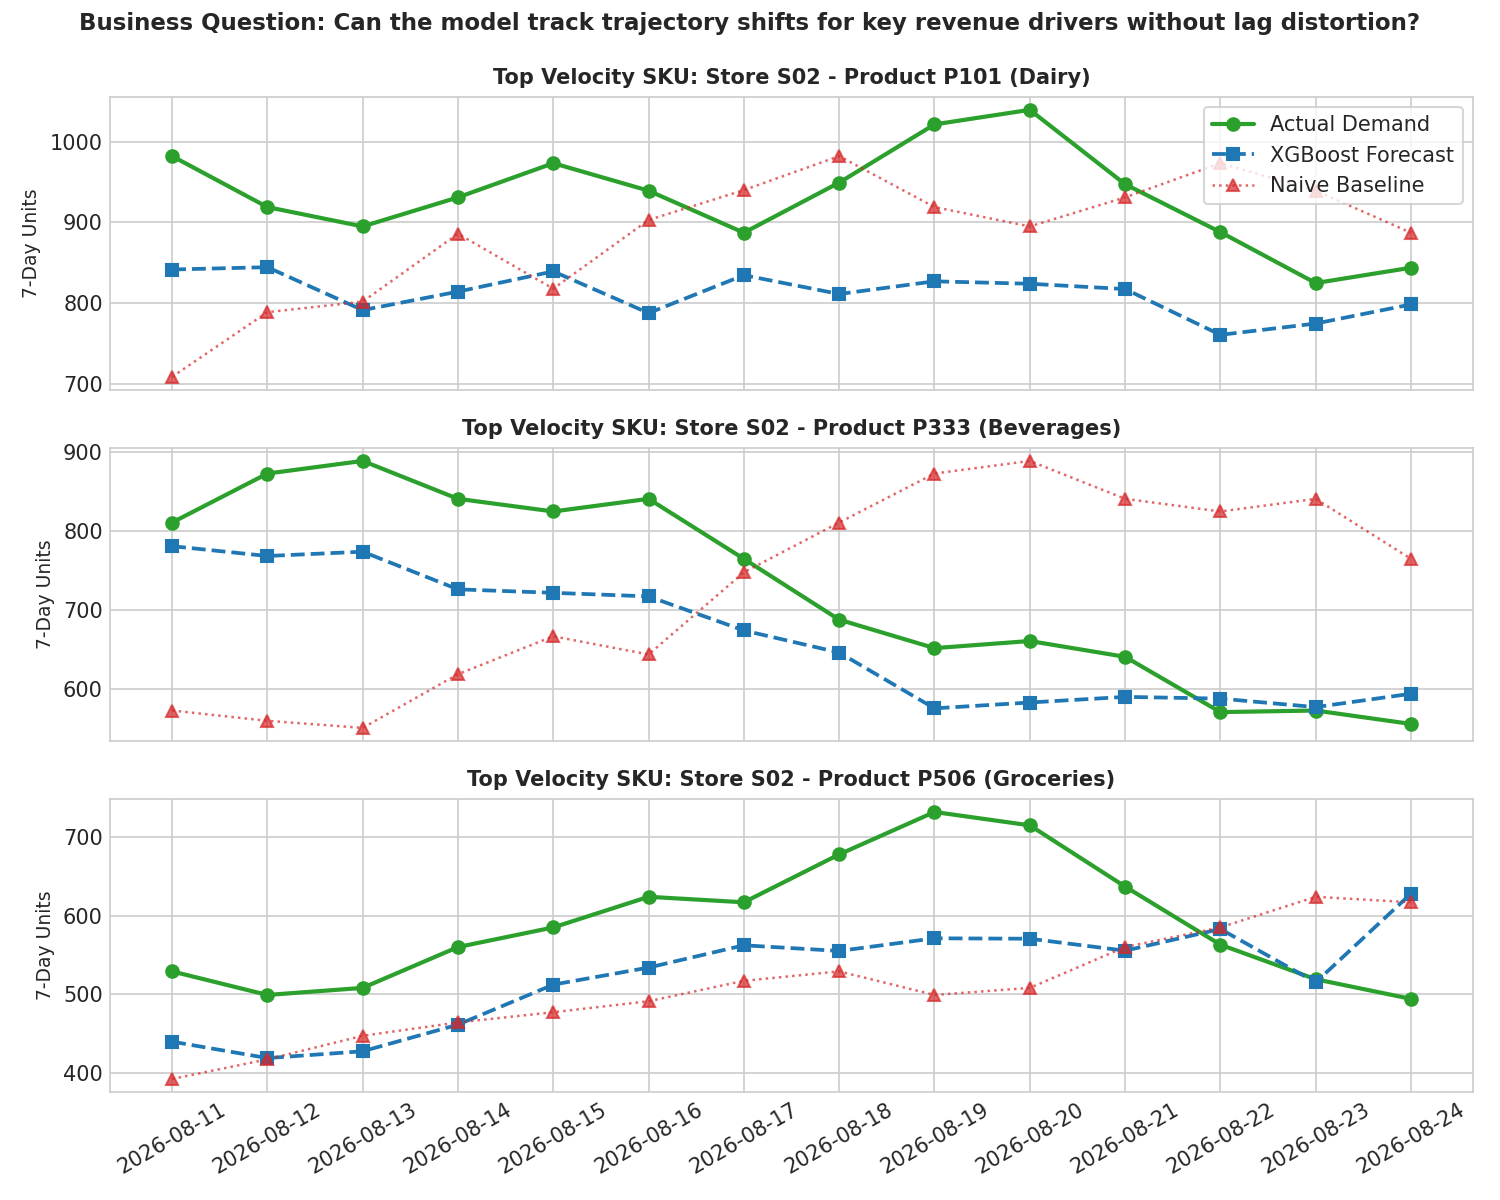

In [6]:
# Display Figure 2: Time Series Tracking for Top SKUs
display(Image.open(FIGURES_DIR / 'model_02_timeseries_top_skus.png'))


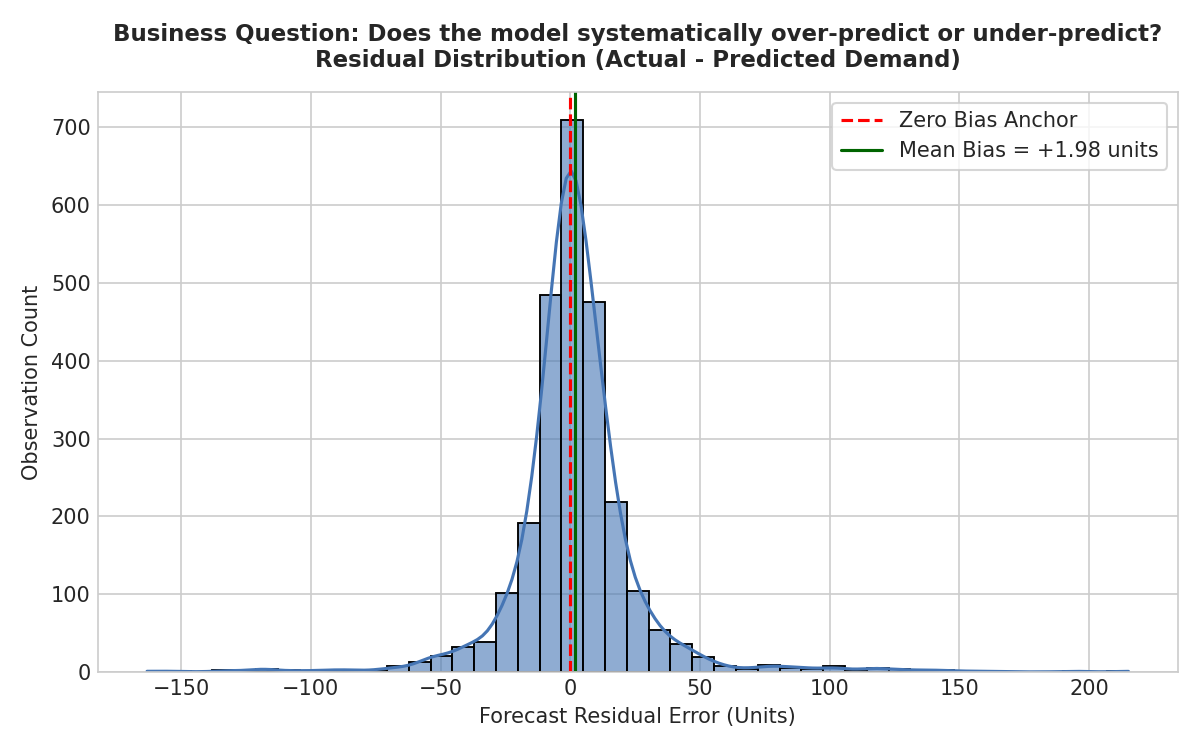

In [7]:
# Display Figure 3: Residual Distribution
display(Image.open(FIGURES_DIR / 'model_03_residual_distribution.png'))


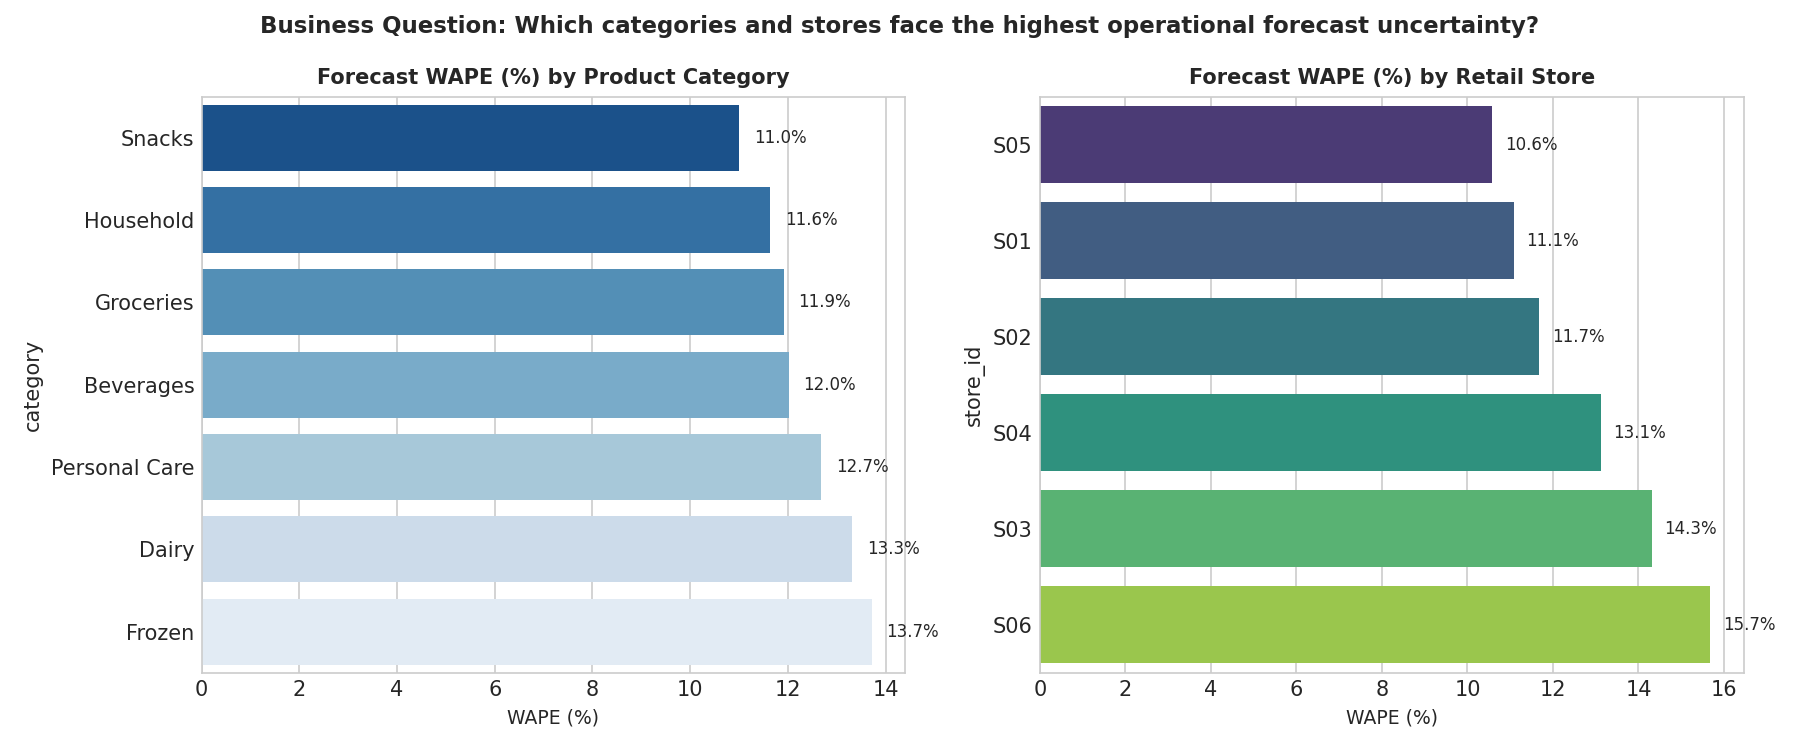

In [8]:
# Display Figure 4: Error by Category and Store
display(Image.open(FIGURES_DIR / 'model_04_error_by_category_store.png'))


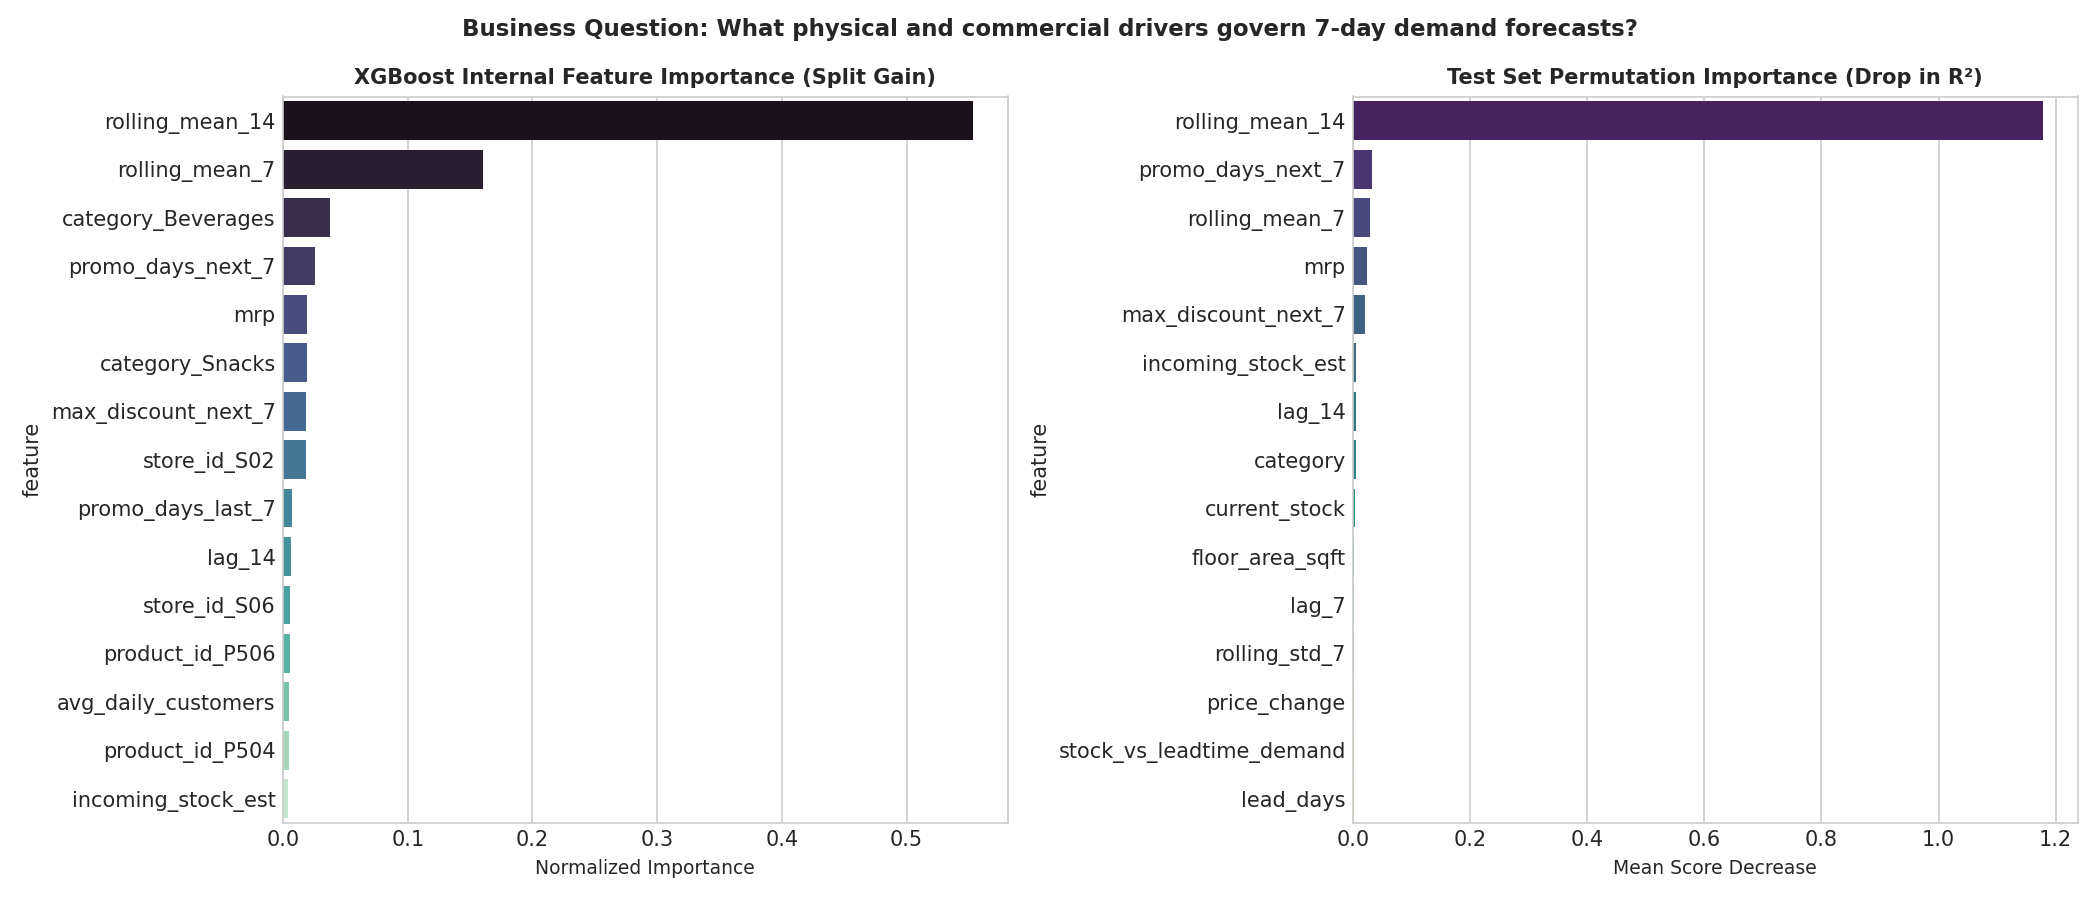

In [9]:
# Display Figure 5: Feature Importance & Explainability
display(Image.open(FIGURES_DIR / 'model_05_feature_importance.png'))


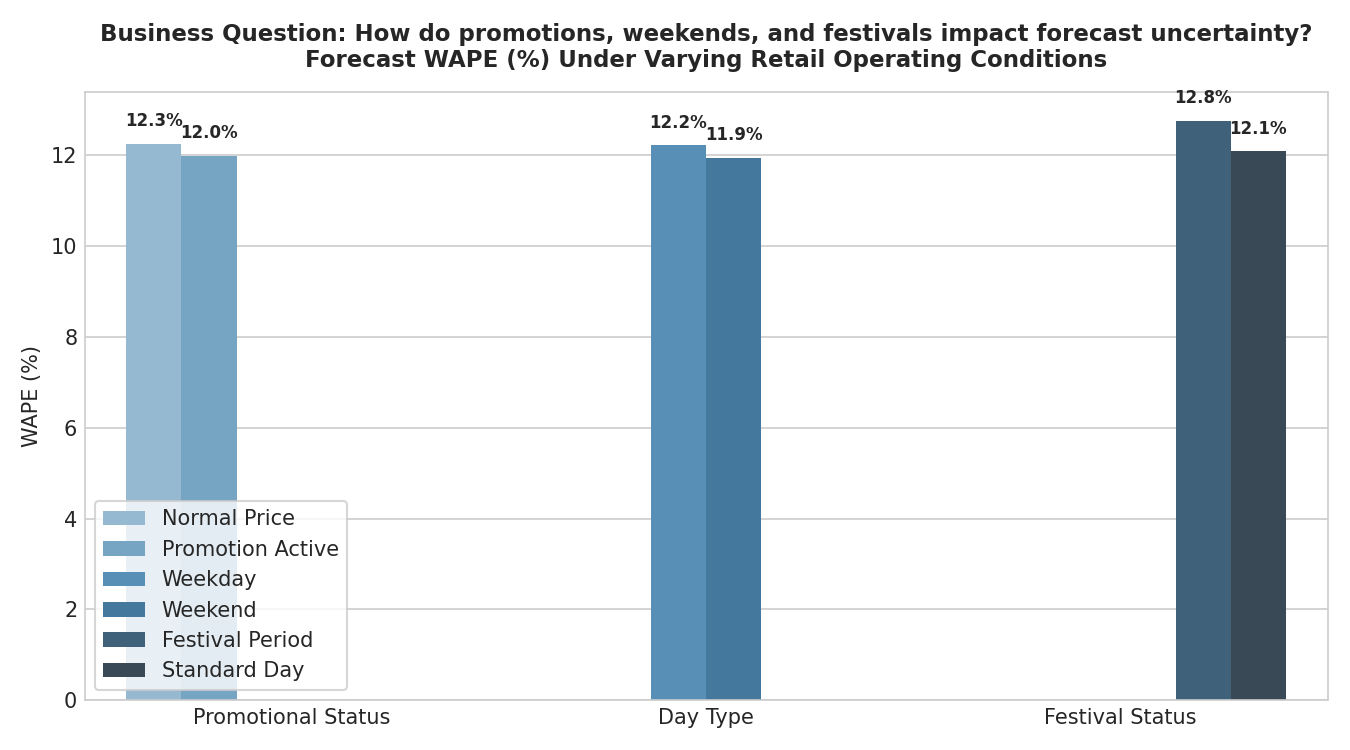

In [10]:
# Display Figure 6: Error Under Retail Operating Conditions
display(Image.open(FIGURES_DIR / 'model_06_error_by_conditions.png'))


## Section 6: Category-Level Forecast Uncertainty for Safety Stock Sizing
**Business Question**: What uncertainty benchmarks should Student 3 (Decision Intelligence) use to calculate safety stock and reorder thresholds?
**What We Do**: Compute category-level RMSE on test predictions and save `reports/forecast_error_by_group.csv`.
**What We Found**: `Beverages` (RMSE = 32.93) and `Dairy` (RMSE = 33.08) exhibit higher unit dispersion, requiring larger safety stock buffers, whereas `Household` (RMSE = 9.25) and `Frozen` (RMSE = 10.52) require lean holding buffers.


In [11]:
group_err = pd.read_csv(REPORTS_DIR / 'forecast_error_by_group.csv')
print("Safety Stock Demand Uncertainty Benchmarks:")
display(group_err)


Safety Stock Demand Uncertainty Benchmarks:


,group_type,group_value,rmse_7day,mae_7day,wape,observation_count
0,overall,All NovaMart SKUs,24.51,14.56,12.14,2583
1,category,Beverages,32.93,20.59,12.02,378
2,category,Dairy,33.08,18.46,13.32,378
3,category,Frozen,10.52,7.78,13.72,338
4,category,Groceries,26.75,16.36,11.92,476
5,category,Household,9.25,6.91,11.64,308
6,category,Personal Care,12.86,9.42,12.68,336
7,category,Snacks,26.96,19.32,11.01,369
8,store_type,Express,13.80,9.48,14.96,838
9,store_type,Hypermarket,46.90,31.55,11.68,468


## Section 7: Live Forward Replenishment Forecasting (As-Of Date 2026-08-31)
**Business Question**: What will sell over the next 7 days (2026-09-01 to 2026-09-07) across all active NovaMart store-SKUs?
**What We Do**: Score all 198 store-products at the prediction cutoff using the refitted champion pipeline, apply hierarchical fallback logic for newly introduced products `P701-P705`, and calculate 10th and 90th percentile prediction bounds (`forecast_low`, `forecast_high`).
**What We Found**: Live forecast generated and saved to `data/processed/forecast_latest.csv`. 100% of SKUs scored with zero negative forecasts.


In [12]:
forecast_live = pd.read_csv(PROCESSED_DIR / 'forecast_latest.csv')
print(f"Total Live SKUs Scored: {len(forecast_live)}")
print("Sample Forward Replenishment Forecasts:")
display(forecast_live.head(10))


Total Live SKUs Scored: 198
Sample Forward Replenishment Forecasts:


,as_of_date,store_id,product_id,forecast_next_7_day_demand,forecast_low,forecast_high,method,confidence
0,2026-08-31,S01,P102,172.08,130.78,232.31,xgboost_regressor,high
1,2026-08-31,S01,P103,50.82,38.62,68.61,xgboost_regressor,high
2,2026-08-31,S01,P104,67.96,51.65,91.75,xgboost_regressor,high
3,2026-08-31,S01,P105,33.39,25.38,45.08,xgboost_regressor,high
4,2026-08-31,S01,P205,57.74,46.77,72.75,xgboost_regressor,high
5,2026-08-31,S01,P206,121.88,98.72,153.57,xgboost_regressor,high
6,2026-08-31,S01,P207,91.09,73.78,114.77,xgboost_regressor,high
7,2026-08-31,S01,P208,49.60,40.18,62.50,xgboost_regressor,high
8,2026-08-31,S01,P330,215.05,174.19,253.76,xgboost_regressor,high
9,2026-08-31,S01,P331,132.61,107.41,156.48,xgboost_regressor,high
